In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

In [2]:
qnumber = 3
qc = QuantumCircuit(qnumber)
qc.h(0)  # Hadamard
qc.cx(0, 1)  # CNOT
qc.h(2)  # Hadamard

display(qc.draw())

┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
     ┌───┐└───┘
q_2: ┤ H ├─────
     └───┘

## Dokładne, wyliczone prawdopodobieństwa

<IPython.core.display.Latex object>

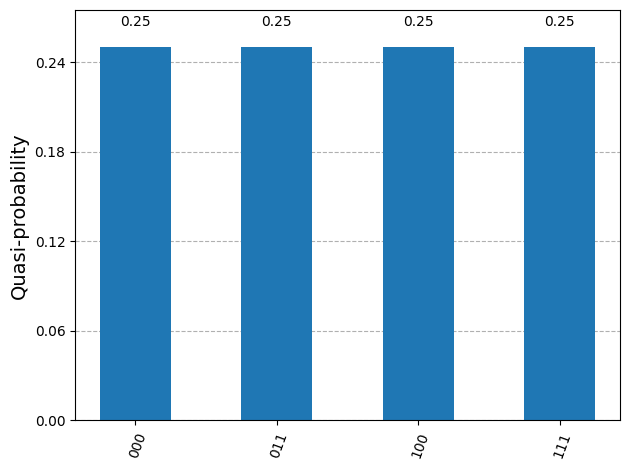

In [3]:
state = Statevector.from_instruction(qc)
ideal_dist = state.probabilities_dict()

display(state.draw("latex"))
display(plot_histogram(ideal_dist))

## Histogramem otrzymany przez próbkowanie zgodnie z prawdopodobieństwami otrzymanymi z wybranego symulatora bez szumów

In [4]:
qc_measure = qc.copy()
qc_measure.measure_all()

display(qc_measure.draw())

┌───┐      ░ ┌─┐      
   q_0: ┤ H ├──■───░─┤M├──────
        └───┘┌─┴─┐ ░ └╥┘┌─┐   
   q_1: ─────┤ X ├─░──╫─┤M├───
        ┌───┐└───┘ ░  ║ └╥┘┌─┐
   q_2: ┤ H ├──────░──╫──╫─┤M├
        └───┘      ░  ║  ║ └╥┘
meas: 3/══════════════╩══╩══╩═
                      0  1  2

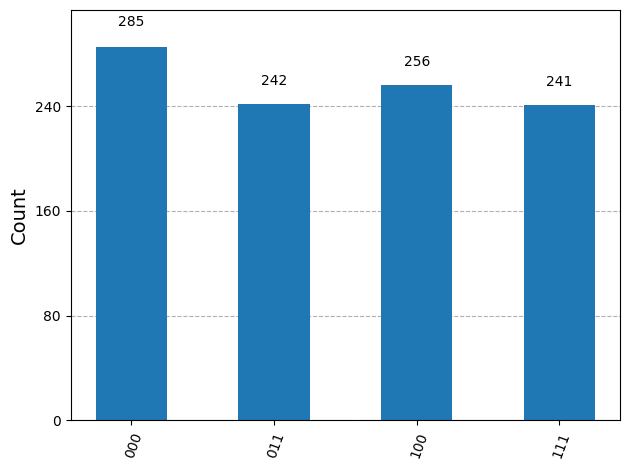

In [5]:
from qiskit_aer import AerSimulator

ideal_simulator = AerSimulator()
ideal_result = ideal_simulator.run(qc_measure, shots=1024).result()
ideal_counts = ideal_result.get_counts()

display(plot_histogram(ideal_counts))

## Histogram z prawdziwego urządzenia kwantowego

qiskit_runtime_service.__init__:WARNING:2026-03-31 02:28:34,068: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-31 02:28:34,070: Using instance: open-instance, plan: open


Selected backend: ibm_fez


global phase: π
           ┌─────────┐┌────┐┌─────────┐                     ░       ┌─┐
q_2 -> 132 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─────────────────────░───────┤M├
           ├─────────┤├────┤├─────────┤                     ░ ┌─┐   └╥┘
q_0 -> 136 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─■───────────────────░─┤M├────╫─
           ├─────────┤├────┤└┬───────┬┘ │ ┌────┐┌─────────┐ ░ └╥┘┌─┐ ║ 
q_1 -> 143 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──■─┤ √X ├┤ Rz(π/2) ├─░──╫─┤M├─╫─
           └─────────┘└────┘ └───────┘    └────┘└─────────┘ ░  ║ └╥┘ ║ 
   meas: 3/════════════════════════════════════════════════════╩══╩══╩═
                                                               0  1  2

Job ID: d75h3ji3qcgc73frokg0
Job status: DONE


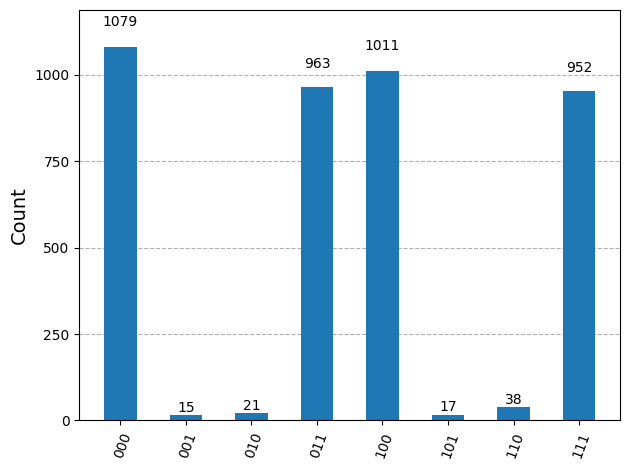

In [6]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

JOB_ID = "d75h3ji3qcgc73frokg0"

service = QiskitRuntimeService()

backend = service.backend("ibm_fez")
print(f"Selected backend: {backend.name}")

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuit = pm.run(qc_measure)

display(isa_circuit.draw())

if not JOB_ID:
    sampler = SamplerV2(backend)
    job = sampler.run([isa_circuit])
else:
    job = service.job(JOB_ID)

print(f"Job ID: {job.job_id()}")
print(f"Job status: {job.status()}")
result = job.result()

ibm_counts = result[0].data.meas.get_counts()
display(plot_histogram(ibm_counts))

## Histogramem otrzymanym przez próbkowanie zgodnie z prawdopodobieństwami otrzymanymi z wybranego symulatora z szumami wg wybranego modelu szumów

global phase: π
           ┌─────────┐┌────┐┌─────────┐                     ░       ┌─┐
  q_2 -> 4 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─────────────────────░───────┤M├
           ├─────────┤├────┤└┬───────┬┘   ┌────┐┌─────────┐ ░    ┌─┐└╥┘
 q_1 -> 96 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──■─┤ √X ├┤ Rz(π/2) ├─░────┤M├─╫─
           ├─────────┤├────┤┌┴───────┴┐ │ └────┘└─────────┘ ░ ┌─┐└╥┘ ║ 
q_0 -> 103 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─■───────────────────░─┤M├─╫──╫─
           └─────────┘└────┘└─────────┘                     ░ └╥┘ ║  ║ 
   meas: 3/════════════════════════════════════════════════════╩══╩══╩═
                                                               0  1  2

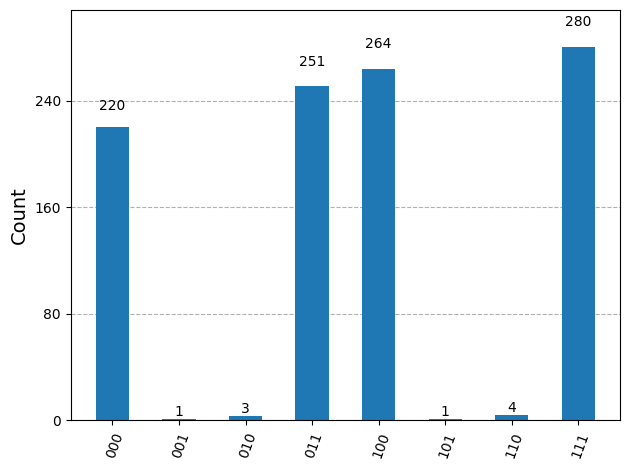

In [7]:
from qiskit_ibm_runtime.fake_provider import FakeFez

backend = FakeFez()
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuit = pm.run(qc_measure)
display(isa_circuit.draw())

sampler = SamplerV2(backend)
job = sampler.run([isa_circuit])
result = job.result()
fake_ibm_counts = result[0].data.meas.get_counts()

display(plot_histogram(fake_ibm_counts))

# Porównanie histogramów

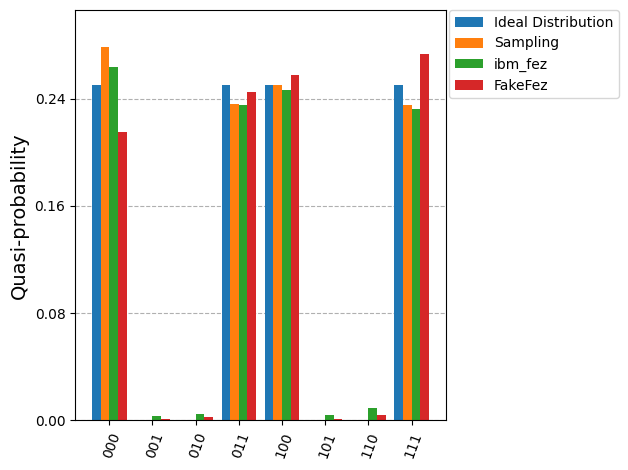

In [8]:
binary_prob = [ideal_dist, ideal_counts, ibm_counts, fake_ibm_counts]
display(
    plot_histogram(
        binary_prob,
        bar_labels=False,
        legend=[
            "Ideal Distribution",
            "Sampling",
            "ibm_fez",
            "FakeFez",
        ],
    )
)